# 해마: 내용 전이와 같은 내용의 이야기 구별

## tl;dr
해마 환자 평균 log-score gain: frozen VP -0.4942, 보정 VP +0.1802. 시각 기준 대비 신경량 추가 이득: identity +0.1974, 같은 identity 안의 story -0.0418. 후향적 같은 참가자 내 비교이며 기전의 인과 증명이 아니다.

## Context & Methods
사진 반응으로 고정한 판독 점수의 방향을 보존하면서, 일부 회상 story에서 확률을 보정하고
남긴 story를 평가한다. 같은 identity 안의 두 story 구별은 별도 분석이다.
이 문서는 저장된 fold 예측에서 지표를 다시 계산하며 모형을 재적합하지 않는다.

### Key Assumptions
- 회상22유닛, 해마16유닛/11세션/5명. 부호화 반응으로 선별된 처리 자료다.
- 네 story는 각각 다른 전체 문맥이다. R1/NR1이 공유 문맥은 아니며 일부 identity는 장소다.
- Identity: R/NR 한 story씩 남기는4fold. 각 시행은 두 번 평가되므로 독립 실험4개가 아니다.
- Conditional story: 동일 identity 두 story의 저장 반복을 반으로 나누고 양방향 평가한다.
  실제 시간 순서·block은 복원할 수 없다. 각 시행은 여기서는 한 번 평가된다.
  Story마다 최소4반복이 필요한 조건으로 편도체2유닛만 제외했다. 해마16유닛은 유지된다.
- 모든 표준화와 적합은 해당 fold의 training 자료만 쓴다. L2 강도는1/n_training으로 고정했다.
- 비교 순서는 동일확률 기준, 고정 VP, 보정 VP, 회상시각만, 신경점수와 회상시각이다.
  선형 log-latency 보정은 모든 행동 교란을 제거하지 않는다.
- 이미 이전 분석에서 전체 자료를 보았으므로 후향적 교차검증이며 새 독립 실험이 아니다.
- Mention 정렬은 이후 알려진 발화 시각을 쓴다. 실시간 온라인 예측기가 아니다.
- 기록 지원·개별 정오답이 미상이며 인과적 주소 기전·생물학적 계량은 추정하지 않는다.

## Data


In [1]:
import hashlib,json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image,display

root = next(p for p in [Path.cwd(),*Path.cwd().parents]
            if (p/'verify/Q-NPF-04/hippocampal_reinstatement/rey_story_transfer_result.json').exists())
folder = root/'verify/Q-NPF-04/hippocampal_reinstatement'
def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()
result_path = folder/'rey_story_transfer_result.json'
result = json.loads(result_path.read_text(encoding='utf-8'))
assert digest(folder/'rey_story_transfer.py')==result['source_sha256']
assert digest(root/'tests/test_rey_story_transfer.py')==result['test_sha256']
for kind in ('source','result'):
    assert digest(root/result['provenance']['prior_'+kind+'_path'])==result['provenance']['prior_'+kind+'_sha256']
assert digest(root/result['provenance']['arrays']['path'])==result['provenance']['arrays']['sha256']
print('Result SHA256:',digest(result_path))
print('Cohort:',result['cohort'])
print('Analysis environment:',result['environment'])
print('Companion numpy/matplotlib:',np.__version__,matplotlib.__version__)
print('No download or refit in this companion.')
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,
                     'figure.facecolor':'white','axes.facecolor':'white'})
figures = folder/'figures'
figures.mkdir(exist_ok=True)


Result SHA256: 3ca0c24580cd6360a884189c6f3802bdb64123d0647d74ed2a88f2896e7f2ca6
Cohort: {'units': 22, 'neuron_trials': 1095, 'unique_behavioural_trials': 680}
Analysis environment: {'python': '3.11.9', 'numpy': '2.4.6', 'scipy': '1.17.1'}
Companion numpy/matplotlib: 2.4.6 3.10.6
No download or refit in this companion.


## Results

### 1. 저장 예측에서 확률 점수 재계산
각fold의 두class를 같은 비중으로 두고 fold→unit→session→participant 순서로 집계한다.
아래 검산은 저장 확률을 직접 사용하며 최적화기를 호출하지 않는다.


In [2]:
checked = 0
for unit in result['units']:
    for branch in ('identity','conditional_story'):
        for fold in unit[branch]['folds']:
            assert not set(fold['training_keys'])&set(fold['test_keys'])
            labels = np.asarray(fold['test_labels'])
            for name,entry in fold['models'].items():
                if name=='chance':
                    continue
                logs = np.asarray(entry['test_log_probs'])
                assert np.isfinite(logs).all()
                np.testing.assert_allclose(np.exp(logs).sum(axis=1),1,atol=1e-12)
                loss = np.mean([-logs[labels==label,label].mean() for label in (0,1)])
                brier = np.mean([np.mean((np.exp(logs[labels==label,1])-label)**2) for label in (0,1)])
                assert abs(loss-entry['scores']['log_loss'])<1e-11
                assert abs(brier-entry['scores']['brier'])<1e-11
                checked += 1
print('Fold/model prediction arrays checked:',checked)
for branch in ('identity','conditional_story'):
    print('\nHippocampus /',branch)
    print('Model                         AUC     Accuracy   Log gain    Brier')
    for name,model in result['summary'][branch]['H']['models'].items():
        vals = [model[key]['participant_mean'] for key in ('auc','accuracy','log_gain','brier')]
        print(f'{name:29s} '+ ' '.join(f'{v:9.4f}' for v in vals))


Fold/model prediction arrays checked: 760

Hippocampus / identity
Model                         AUC     Accuracy   Log gain    Brier
frozen_vp                        0.8107    0.6486   -0.4942    0.2745
chance                           0.5000    0.5000   -0.0000    0.2500
calibrated_vp                    0.8085    0.7383    0.1802    0.1704
latency_only                     0.6114    0.5857    0.0274    0.2324
calibrated_vp_plus_latency       0.8420    0.7846    0.2248    0.1526
precue_calibrated                0.4845    0.4772   -0.0117    0.2552

Hippocampus / conditional_story
Model                         AUC     Accuracy   Log gain    Brier
chance                           0.5000    0.5000    0.0000    0.2500
latency_only                     0.5660    0.5364   -0.0559    0.2692
premention_count                 0.5646    0.5519   -0.0357    0.2631
premention_plus_latency          0.5961    0.5688   -0.0977    0.2823
precue_plus_latency              0.5560    0.4990   -0.0871    0.27

### 2. Probability transfer and story-condition discrimination
Log-score gain이0보다 커야50:50 예측보다 좋다. 작은 점은 각 참가자의 요약, 큰 마름모는
참가자 평균이다. 점의 퍼짐은 신뢰구간이 아니다. 두 패널의 세로축 범위는 다르다.


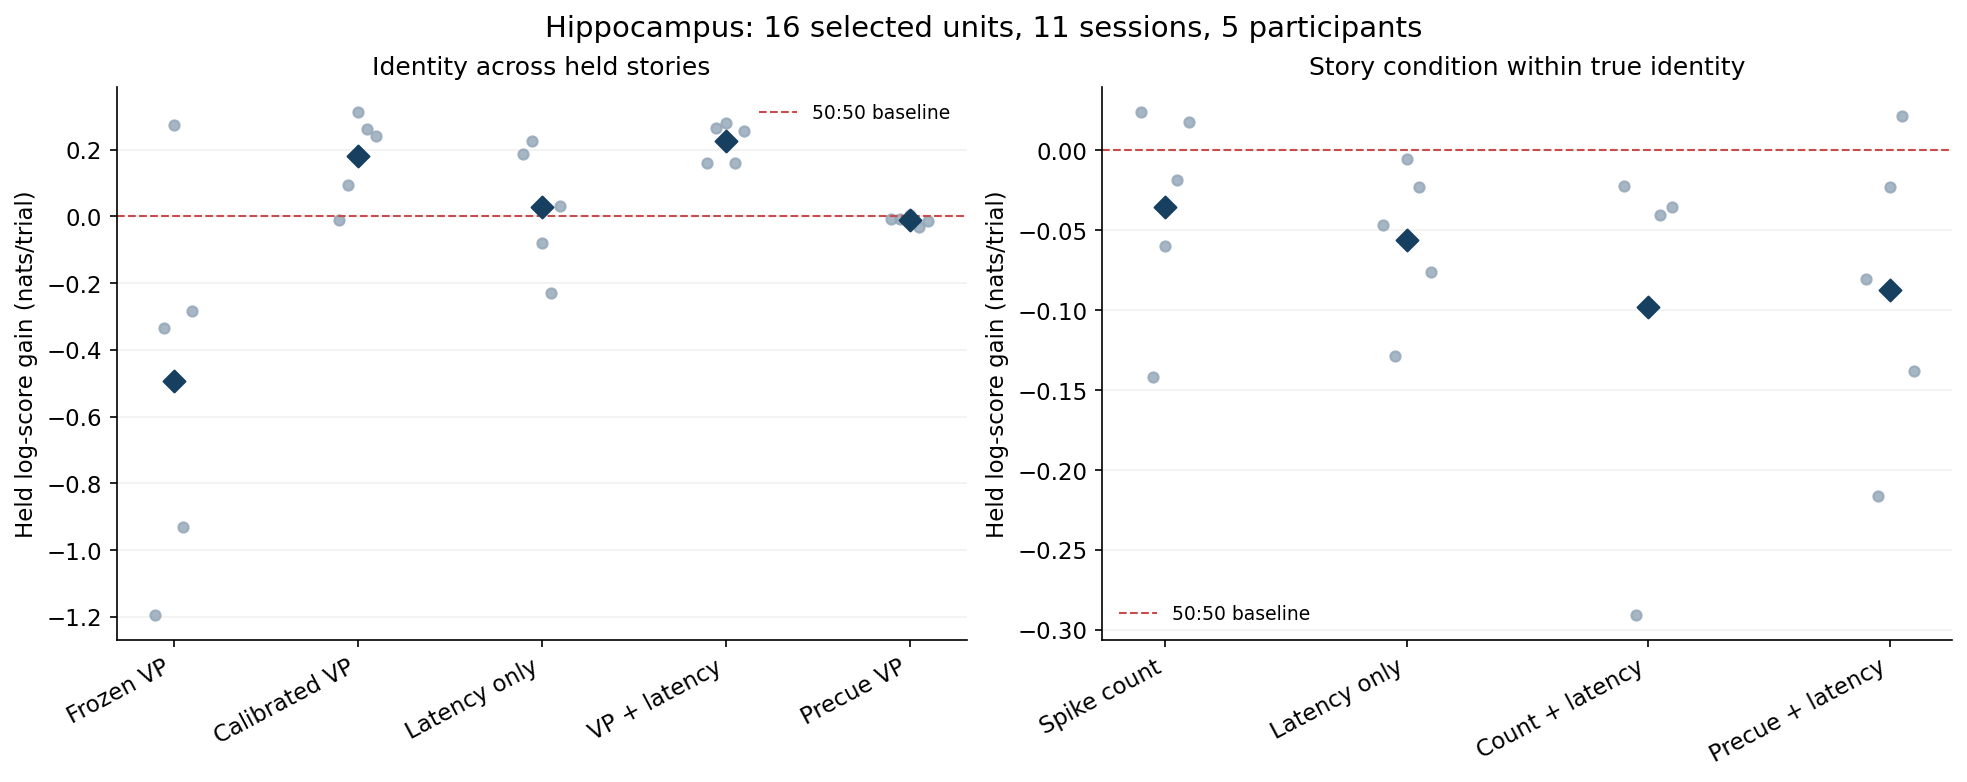

In [3]:
panels = [
 ('identity',['frozen_vp','calibrated_vp','latency_only','calibrated_vp_plus_latency','precue_calibrated'],
  ['Frozen VP','Calibrated VP','Latency only','VP + latency','Precue VP'], 'Identity across held stories'),
 ('conditional_story',['premention_count','latency_only','premention_plus_latency','precue_plus_latency'],
  ['Spike count','Latency only','Count + latency','Precue + latency'], 'Story condition within true identity')]
fig,axes = plt.subplots(1,2,figsize=(13,5.1),layout='constrained')
for ax,(branch,names,labels,title) in zip(axes,panels):
    for i,name in enumerate(names):
        metric = result['summary'][branch]['H']['models'][name]['log_gain']
        values = list(metric['by_participant'].values())
        jitter = np.linspace(-.1,.1,len(values))
        ax.scatter(i+jitter,values,color='#91A4B6',s=24,alpha=.8,zorder=2)
        ax.scatter(i,metric['participant_mean'],marker='D',color='#173F5F',s=55,zorder=3)
    ax.axhline(0,color='#C94C4C',lw=1,ls='--',label='50:50 baseline')
    ax.set_xticks(range(len(names)),labels,rotation=28,ha='right')
    ax.set_ylabel('Held log-score gain (nats/trial)')
    ax.set_title(title,fontsize=12)
    ax.grid(axis='y',alpha=.18)
    ax.legend(frameon=False,fontsize=9)
fig.suptitle('Hippocampus: 16 selected units, 11 sessions, 5 participants',fontsize=14)
path = figures/'rey_transfer_proper_scores.png'
fig.savefig(path,dpi=150,bbox_inches='tight')
display(Image(filename=str(path)))
plt.close(fig)


### 3. Increment over response timing
같은fold에서 신경량과log-latency를 쓰는 모형의log-score gain에서log-latency만 쓰는 모형의
값을 뺀다. 양수면 이 특정한 선형 모형 비교에서 추가 예측 정보가 있다. 인과 효과는 아니다.


Identity: VP increment {'1': -0.027847829892860027, '2': 0.041104283947218156, '3': 0.3587045346215236, '5': 0.3889854670385534, '8': 0.2262479101336231}
Story: count increment {'1': 0.02466082846708298, '2': -0.1623564022014339, '3': -0.09448828073079733, '5': -0.017442413978661475, '8': 0.040633486787230964}


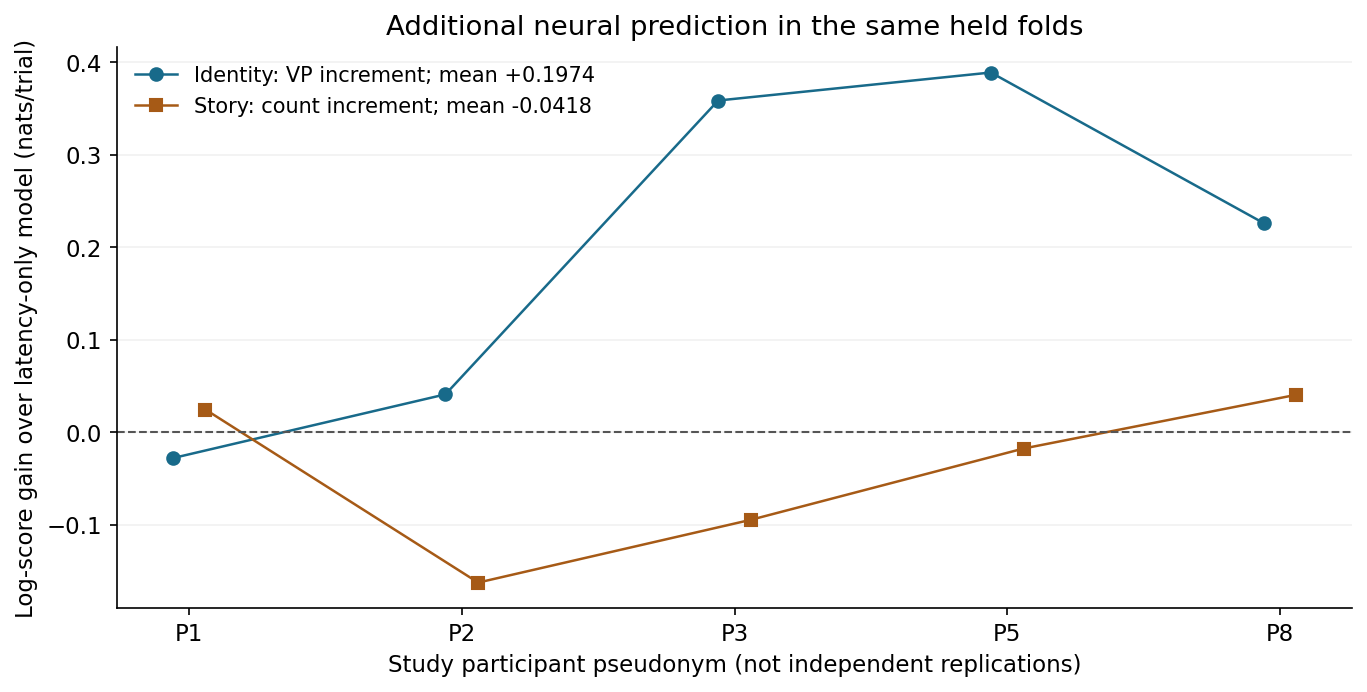

In [4]:
fig,ax = plt.subplots(figsize=(9,4.5),layout='constrained')
for branch,name,label,color,marker,offset in (
    ('identity','calibrated_vp_plus_latency','Identity: VP increment','#186A8A','o',-.06),
    ('conditional_story','premention_plus_latency','Story: count increment','#A65A16','s',.06)):
    models = result['summary'][branch]['H']['models']
    neural = models[name]['log_gain']['by_participant']
    timing = models['latency_only']['log_gain']['by_participant']
    people = sorted(neural,key=int)
    delta = np.array([neural[p]-timing[p] for p in people])
    ax.plot(np.arange(len(people))+offset,delta,marker=marker,color=color,lw=1.2,label=f'{label}; mean {delta.mean():+.4f}')
    print(label,dict(zip(people,delta.tolist())))
ax.axhline(0,color='#555555',ls='--',lw=1)
ax.set_xticks(np.arange(len(people)),['P'+p for p in people])
ax.set_xlabel('Study participant pseudonym (not independent replications)')
ax.set_ylabel('Log-score gain over latency-only model (nats/trial)')
ax.set_title('Additional neural prediction in the same held folds')
ax.grid(axis='y',alpha=.18)
ax.legend(frameon=False,fontsize=10)
path = figures/'rey_transfer_incremental.png'
fig.savefig(path,dpi=150,bbox_inches='tight')
display(Image(filename=str(path)))
plt.close(fig)


## Takeaways
내용 구별, 확률 보정, 같은 내용의 다른story 조건 구별은 별도의 검증 대상이다.
50:50보다 나은 확률 예측과latency-only를 넘는 증가분을 함께 확인하고 점 추정을
모집단 효과로 확대하지 않는다. 모든 그림은 같은 선별된 후향적 자료에 근거하며 독립 실험이 아니다.

원기록의 획득 범위·개별 정오답·완전한cue/story 의미·실제 제시 순서는 복구되지 않는다.
이 결과만으로 해마의 사건 주소, 전기적 전달식, 학습에 따른 생물학적 리만 계량을
식별할 수 없다. 다음 기전 검증에는 같은 단위의 문맥·내용·방향성을 나누는 관측이 필요하다.
